# ETFs: Label Engineering

Every model in this case study is trained to predict the label. An error in it produces no
warning here and changes every result that follows, so this notebook defines the labels,
checks the definition, sets the floor a feature must clear, and writes the label files every
later stage of the case study trains and scores against.

## Learning objectives

- Write a forward-return label as a formula: from which price at which time, to which
  price at which time
- Check that every labelled row has a complete forward window inside one symbol
- Measure how much independent information an overlapping label carries, and keep a
  diagnostic clear of the holdout by the date each label resolves rather than the date it
  is observed
- Measure what one unengineered signal earns against the label, on the same rows the
  feature work will be scored on, so later work is compared against a floor fixed first

## Book reference, prerequisites and artifacts

Chapter 7, Section 7.2. Reads split- and dividend-adjusted daily bars via `load_etfs()`
(verified in [`01_feasibility_analysis`](01_feasibility_analysis.ipynb)) and
`config/setup.yaml`, which declares the label set, horizons and holdout boundary. Writes
`labels/fwd_ret_21d.parquet` and `labels/fwd_ret_5d.parquet`. The first notebook to open
them is [`05_evaluation`](05_evaluation.ipynb), which scores engineered features against
the primary label; the model notebooks from `06_linear.py` onward load whichever label they
train on, and the cross-validation folds are cut from that file's own timeline.

In [1]:
"""ETFs: Label Engineering."""

import math
import warnings
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series

from case_studies.utils.artifact_digest import value_digest, write_artifact
from case_studies.utils.label_diagnostics import effective_sample_size, panel_autocorrelation
from data import load_etfs
from utils.artifact_specs import resolve_label_horizon
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title

warnings.filterwarnings("ignore")

CASE_DIR = get_case_study_dir("etfs")
LABELS_DIR = CASE_DIR / "labels"

`MAX_SYMBOLS` and `START_DATE` cut the universe and the history for a shorter run; both are
unset here. `MIN_SYMBOLS_FOR_DISPERSION` sets the smallest cross-section Section E will take
a standard deviation over.

In [2]:
MAX_SYMBOLS = None
START_DATE = None
MIN_SYMBOLS_FOR_DISPERSION = 10

## Configuration

Every value that defines a label comes from `config/setup.yaml`: the label set, the
horizons and the holdout boundary. `resolve_label_horizon` reads `labels.horizons` where a
case study declares it and falls back to the cross-validation buffer, which here is the
same number.

In [3]:
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

PRIMARY_LABEL = setup["labels"]["primary"]
LABEL_NAMES = [PRIMARY_LABEL, *setup["labels"].get("variants", [])]
HORIZONS = {n: int(resolve_label_horizon("etfs", n, setup).rstrip("Dd")) for n in LABEL_NAMES}
HOLDOUT_START = date.fromisoformat(setup["evaluation"]["holdout_start"])
PRIMARY_HORIZON = HORIZONS[PRIMARY_LABEL]
VARIANT_LABEL = LABEL_NAMES[1]

print(
    f"The primary label {PRIMARY_LABEL} is a forward return over {PRIMARY_HORIZON} trading "
    "sessions - the horizon a monthly hold spans, and the one every model here is trained on."
    f"\nThe variant {VARIANT_LABEL} is the same construction over {HORIZONS[VARIANT_LABEL]} "
    "sessions, which is what a weekly hold would need."
    f"\nEverything from {HOLDOUT_START} onward is left for the final test. A row belongs to the "
    "development window only when its forward window closes before that date, not merely when "
    "it is observed before it."
)

The primary label fwd_ret_21d is a forward return over 21 trading sessions - the horizon a monthly hold spans, and the one every model here is trained on.
The variant fwd_ret_5d is the same construction over 5 sessions, which is what a weekly hold would need.
Everything from 2024-01-01 onward is left for the final test. A row belongs to the development window only when its forward window closes before that date, not merely when it is observed before it.


## A. The learning task

The hypothesis is cross-sectional: among a fixed universe of liquid ETFs, those that rose
over the past two quarters continue to outrank those that did not over the following month.
The label itself is each ETF's own forward return over a window a monthly hold spans; what
makes the statement a relative one is how the label is scored, by rank correlation across
the ETFs quoted on a date rather than by the level any one of them reached.
`setup.yaml` sets the decision cadence to a month-end close with execution at the next open,
which fixes the primary horizon at one trading month. The weekly variant asks whether the
same hypothesis pays over a shorter hold, which is a question about turnover and cost.

Labels are sampled every session rather than only at month ends. That gives an order of
magnitude more rows, and consecutive rows then overlap; Section F measures how much
independent information they carry.

## B. Preparation before the label

A forward window is meaningful only on a price series that is adjusted, ordered and
complete; sorting by `symbol` then `timestamp` is what makes a shift mean "the next session
for this ETF".

The labels are built on the full price history, and the eligibility rules in
`eligibility.csv` are applied afterwards - to the Section G baseline, and to the trainable
panel in `03_financial_features`. The order is what keeps the horizon in trading sessions:
a shift of $h$ counts $h$ rows of whatever frame it runs on, so it has to run on the frame
that still has every session in it.

The panel is unbalanced, which matters from Section E onward: several of these ETFs listed
after the history starts, so the number of symbols quoting on a date is not the size of the
universe. Every cross-sectional quantity below - the spread within a date, the rank
correlation - is computed over whatever is quoting that day, and needs a minimum before it
means anything.

The *digest* printed below is a hash of the price values the labels are built from, taken
over the symbol, timestamp and close columns the cell reads. Section H writes it beside each
label file, so a stored label can be traced back to the download it came from.

In [4]:
prices = load_etfs().select(["symbol", "timestamp", "close"]).sort(["symbol", "timestamp"])

if START_DATE is not None:
    prices = prices.filter(pl.col("timestamp") >= date.fromisoformat(START_DATE))
if MAX_SYMBOLS is not None:
    prices = prices.filter(
        pl.col("symbol").is_in(sorted(prices["symbol"].unique().to_list())[:MAX_SYMBOLS])
    )

MARKET_DATA_DIGEST = value_digest(prices, ["symbol", "timestamp", "close"])

per_session = prices.group_by("timestamp").len().sort("timestamp")

print(
    f"{prices['symbol'].n_unique()} ETFs, {len(prices):,} rows, sessions "
    f"{prices['timestamp'].min()} to {prices['timestamp'].max()}"
    f"\n{per_session['len'].item(0)} of them quote on the first session and "
    f"{per_session['len'].item(-1)} on the last, so the cross-section fills in over the history"
    f"\nmarket_data digest: {MARKET_DATA_DIGEST}"
)

100 ETFs, 470,662 rows, sessions 2006-01-03 to 2025-12-31
59 of them quote on the first session and 100 on the last, so the cross-section fills in over the history
market_data digest: eef04b58a9ea0b97


## C. Label construction

One execution convention, written once, applied to both horizons:

$$r^{(h)}_{i,t} = \frac{P_{i,t+h}}{P_{i,t}} - 1$$

where $P$ is the adjusted close and $t+h$ counts $h$ **trading sessions** for symbol $i$.
This is Chapter 7.2's close-to-close convention. The two labels, written to columns
`fwd_ret_21d` and `fwd_ret_5d`, share the anchor and differ only in $h$.

Two bookkeeping columns are numbered alongside them, on the complete price series before any
row is dropped: `from_end` counts back from each symbol's last session for Section D, and
`session` numbers its bars forward for Section F. Neither is written to the label parquet.

In [5]:
def forward_return(df: pl.DataFrame, horizon: int, name: str) -> pl.DataFrame:
    """Close-to-close forward return over `horizon` trading sessions, per symbol."""
    return df.with_columns(
        (pl.col("close").shift(-horizon).over("symbol") / pl.col("close") - 1).alias(name)
    )


labels_df = prices.with_columns(
    (pl.len().over("symbol") - 1 - pl.int_range(pl.len()).over("symbol")).alias("from_end"),
    pl.int_range(pl.len()).over("symbol").alias("session"),
)
for label_name, horizon in HORIZONS.items():
    labels_df = forward_return(labels_df, horizon, label_name)

print(f"Constructed {', '.join(LABEL_NAMES)}")

Constructed fwd_ret_21d, fwd_ret_5d


## D. Window validity

A shift always returns something; the question is whether it is the quantity the label
claims. Four properties have to hold, and each fails without raising an error, so the cell
below checks them with `assert`:

1. A row whose forward window is incomplete carries a null, never a value.
2. No labelled window spans a gap in the data. The tolerance is derived rather than tuned:
   $h$ trading sessions cover about $7h/5$ calendar days on a five-session week, plus a
   week for exchange holidays.
3. No label crosses from one symbol into the next. The labelled row count equals the bar
   count less $h$ rows per symbol, which holds only if every window closed inside the
   symbol it opened in.
4. No discrete label is derived from a null return. Both labels here are continuous, so
   this is a check on their dtype.

Property 2 measures the window in calendar days, so it catches a hole of a week or more and
not a single missing session. An exact session count needs an exchange calendar.

In [6]:
for label_name, horizon in HORIZONS.items():
    tol = math.ceil(horizon * 7 / 5) + 7
    # How many calendar days the forward window actually spans, for property 2.
    spanned = labels_df.with_columns(
        (pl.col("timestamp").shift(-horizon).over("symbol") - pl.col("timestamp"))
        .dt.total_days()
        .alias("_span")
    )
    tail = spanned.filter(pl.col("from_end") < horizon)
    labelled = spanned.drop_nulls(label_name)

    # 1.
    assert tail[label_name].null_count() == tail.height, f"{label_name}: valued incomplete window"
    # 2.
    assert labelled.filter(pl.col("_span") > tol).height == 0, f"{label_name}: window gap"
    # 3.
    assert labelled.height == len(prices) - horizon * prices["symbol"].n_unique(), (
        f"{label_name}: label crosses a symbol boundary"
    )
    # 4.
    assert labels_df.schema[label_name] == pl.Float64, f"{label_name}: unexpected dtype"

    spans = labelled["_span"]
    print(
        f"{label_name}: {labelled.height:,} labelled rows, spans {spans.min()}-{spans.max()}d "
        f"against a {tol}d tolerance, {tail.height:,} tail rows null"
    )

fwd_ret_21d: 468,562 labelled rows, spans 29-35d against a 37d tolerance, 2,100 tail rows null
fwd_ret_5d: 470,162 labelled rows, spans 7-12d against a 14d tolerance, 500 tail rows null


The assertions stop the run, but they do not show *where* each label ends. The figure below
does. Position zero is each symbol's last session, and the share of symbols carrying a label
falls to zero over exactly the last `horizon` positions and sits flat at one before them.

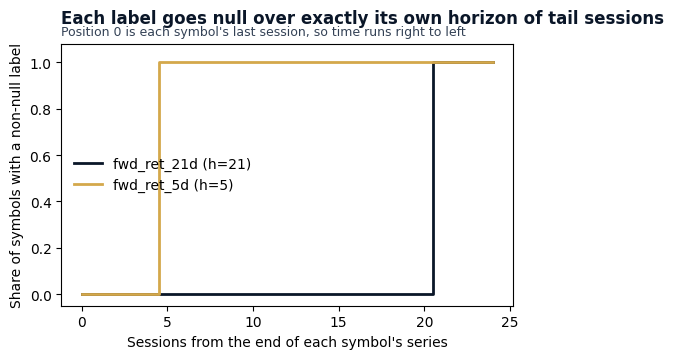

In [7]:
profile = (
    labels_df.filter(pl.col("from_end") <= max(HORIZONS.values()) + 3)
    .group_by("from_end")
    .agg([pl.col(n).is_not_null().mean().alias(n) for n in LABEL_NAMES])
    .sort("from_end")
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for label_name, color in zip(LABEL_NAMES, (COLORS["blue"], COLORS["amber"]), strict=True):
    ax.step(
        profile["from_end"],
        profile[label_name],
        where="mid",
        color=color,
        linewidth=2,
        label=f"{label_name} (h={HORIZONS[label_name]})",
    )
ax.set_xlabel("Sessions from the end of each symbol's series")
ax.set_ylabel("Share of symbols with a non-null label")
ax.set_ylim(-0.05, 1.08)
add_message_title(
    ax,
    "Each label goes null over exactly its own horizon of tail sessions",
    subtitle="Position 0 is each symbol's last session, so time runs right to left",
)
ax.legend(loc="center left", frameon=False)
plt.show()

## E. Distribution and base rate

What scale is the label, and is it stable enough through time that a model fitted on one
regime measures the same quantity in another? Everything from here through Section G is
computed on the **development window only**, and the cut is made on the date each label
resolves rather than the date it is observed. A row observed a week before the holdout
begins has its forward window closing inside the holdout, so it is a holdout row and a
filter on the observation date would have left it in. The label files themselves keep every
row; it is only the diagnostics that are restricted.

In [8]:
dev = {
    name: labels_df.with_columns(
        pl.col("timestamp").shift(-horizon).over("symbol").alias("_label_end")
    )
    .filter(pl.col("_label_end") < HOLDOUT_START)
    .drop_nulls(name)
    for name, horizon in HORIZONS.items()
}
for label_name, frame in dev.items():
    print(f"{label_name}: {frame.height:,} development rows through {frame['timestamp'].max()}")

fwd_ret_21d: 418,362 development rows through 2023-11-29
fwd_ret_5d: 419,962 development rows through 2023-12-21


Both labels are drawn on one axis with identical bins, so their shapes can be compared
directly. What to look for: a label over $h$ sessions should be about $\sqrt{h}$ times as
wide as a one-session label, and the legend carries each one's standard deviation.

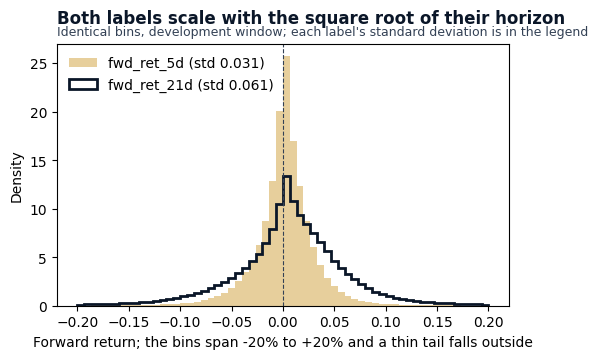

In [9]:
bins = np.linspace(-0.20, 0.20, 61)
std = {n: dev[n][n].std() for n in LABEL_NAMES}
ratio = std[PRIMARY_LABEL] / std[VARIANT_LABEL]
theory = math.sqrt(PRIMARY_HORIZON / HORIZONS[VARIANT_LABEL])

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
fills = {VARIANT_LABEL: dict(color=COLORS["amber"], alpha=0.55)}
fills[PRIMARY_LABEL] = dict(color=COLORS["blue"], histtype="step", linewidth=2)
for label_name in (VARIANT_LABEL, PRIMARY_LABEL):
    ax.hist(
        dev[label_name][label_name].to_numpy(),
        bins=bins,
        density=True,
        label=f"{label_name} (std {std[label_name]:.3f})",
        **fills[label_name],
    )
ax.axvline(0, color=COLORS["neutral"], linestyle="--", linewidth=0.8)
ax.set_xlabel("Forward return; the bins span -20% to +20% and a thin tail falls outside")
ax.set_ylabel("Density")
add_message_title(
    ax,
    "Both labels scale with the square root of their horizon",
    subtitle="Identical bins, development window; each label's standard deviation is in the legend",
)
ax.legend(loc="upper left", frameon=False)
plt.show()

The second stability question is about the spread the model ranks within. A cross-sectional
model is scored on how well it orders symbols on a date, so the return that ordering earns
depends on how far apart the symbols are that day: at twice the spread, the same
information coefficient returns twice as much.

The spread is measured across symbols within each date, and those daily values are then
averaged over the year.

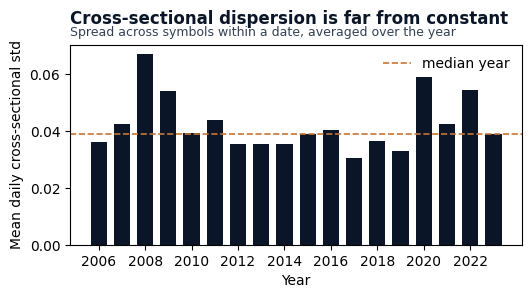

scale: std ratio 1.97 against 2.05 under root-horizon scaling; dispersion peaks at 6.7% in 2008 against a 3.9% median year


In [10]:
daily_dispersion = (
    dev[PRIMARY_LABEL]
    .group_by("timestamp")
    .agg(pl.col(PRIMARY_LABEL).std().alias("dispersion"), pl.len().alias("n_symbols"))
    .filter(pl.col("n_symbols") >= MIN_SYMBOLS_FOR_DISPERSION)
)
annual = (
    daily_dispersion.with_columns(pl.col("timestamp").dt.year().alias("year"))
    .group_by("year")
    .agg(pl.col("dispersion").mean().alias("dispersion"))
    .sort("year")
)
peak = annual.sort("dispersion", descending=True).row(0, named=True)
median_disp = annual["dispersion"].median()

fig, ax = plt.subplots(figsize=FIGSIZE["single_wide"])
ax.bar(annual["year"], annual["dispersion"], color=COLORS["blue"], width=0.7)
ax.axhline(median_disp, color=COLORS["copper"], linestyle="--", linewidth=1.2, label="median year")
ax.set_xticks(annual["year"].to_list()[::2])  # integer years, not a float axis
ax.set_xlabel("Year")
ax.set_ylabel("Mean daily cross-sectional std")
add_message_title(
    ax,
    "Cross-sectional dispersion is far from constant",
    subtitle="Spread across symbols within a date, averaged over the year",
)
ax.legend(loc="upper right", frameon=False)
plt.show()

print(
    f"scale: std ratio {ratio:.2f} against {theory:.2f} under root-horizon scaling; "
    f"dispersion peaks at {peak['dispersion']:.1%} in {peak['year']:.0f} "
    f"against a {median_disp:.1%} median year"
)

On the development window the monthly label has a standard deviation of 0.0612 against
0.0311 for the weekly label - a ratio of 1.97, close to the 2.05 that
square-root-of-horizon scaling would give. Cross-sectional dispersion is far from
constant: it peaks at 6.7% in 2008, against a median year of 3.9%.

## F. Overlap and effective sample size

Daily sampling of a multi-session label makes consecutive rows share most of their forward
window, so the row count overstates how much the sample actually tells us. Two measurements
follow: how fast the overlap decays, and what the row count is worth once the overlap is
accounted for. `effective_sample_size` applies Chapter 7.2's average-uniqueness weighting
one symbol at a time, since it is only one symbol's own windows that overlap each other.

A label over $h$ sessions is built from the $h$ returns realised inside its window, and the
label one session later shares $h-1$ of them. Average uniqueness therefore approaches $1/h$
and the effective count approaches $N/h$.

Both measurements count lags on `session`, the grid the label was built on, and not on
position among the rows that reach `dev`. Where a bar is missing, the surviving rows close
over the hole, and two windows that share no return get counted as one session apart.

The figure below shows how fast the overlap decays, pooled across the whole panel so that
the answer is a property of the label rather than of any one ETF.

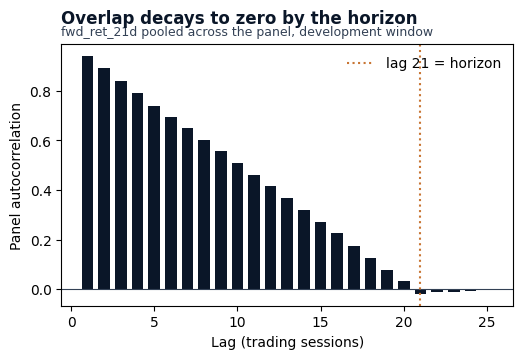

fwd_ret_21d: N=418,362 N_eff=20,017 (4.78% of N, against 4.76% for windows that overlap as fully as this one)
  autocorrelation at lag one 0.942, at the horizon -0.019


In [11]:
max_lag = PRIMARY_HORIZON + 4
acf = panel_autocorrelation(dev[PRIMARY_LABEL], PRIMARY_LABEL, max_lag=max_lag, bar_col="session")
n_rows, n_eff = effective_sample_size(
    dev[PRIMARY_LABEL], horizon=PRIMARY_HORIZON, bar_col="session"
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.bar(np.arange(1, max_lag + 1), acf, color=COLORS["blue"], width=0.7)
ax.axhline(0, color=COLORS["neutral"], linewidth=0.8)
ax.axvline(
    PRIMARY_HORIZON,
    color=COLORS["copper"],
    linestyle=":",
    linewidth=1.5,
    label=f"lag {PRIMARY_HORIZON} = horizon",
)
ax.set_xlabel("Lag (trading sessions)")
ax.set_ylabel("Panel autocorrelation")
add_message_title(
    ax,
    "Overlap decays to zero by the horizon",
    subtitle=f"{PRIMARY_LABEL} pooled across the panel, development window",
)
ax.legend(loc="upper right", frameon=False)
plt.show()

print(
    f"{PRIMARY_LABEL}: N={n_rows:,} N_eff={n_eff:,.0f} ({n_eff / n_rows:.2%} of N, against "
    f"{1 / PRIMARY_HORIZON:.2%} for windows that overlap as fully as this one)"
)
print(f"  autocorrelation at lag one {acf[0]:.3f}, at the horizon {acf[PRIMARY_HORIZON - 1]:.3f}")

The monthly label's 418,362 development rows carry 20,017 effective observations, 4.78% of
the row count against the 4.76% implied by a window this fully overlapped. Panel
autocorrelation runs from 0.942 at lag one to -0.019 at the horizon.

## G. Baseline floor

One signal, against the primary label, on the development window: the raw momentum the
hypothesis names, with no feature engineering. Measuring it first is what keeps a later
improvement honest, because every engineered feature is then compared against a number that
was fixed before the feature existed.

The signal is scored the same way every feature will be. The IC is the cross-sectional rank
correlation - the correlation between the order momentum puts the ETFs in on a date and the
order their forward returns turn out in - computed within each date and then averaged over
dates. The standard error is HAC-adjusted, because the IC series inherits the label's
overlap and correlated dates are not independent evidence.

The baseline is measured on the same rows the features will be measured on:
`03_financial_features` keeps a feature row only where the `(symbol, year)` pair appears in
`eligibility.csv`, so the same semi-join runs here.

In [12]:
LOOKBACK = 126  # two quarters, the momentum window the hypothesis names

eligibility = pl.read_csv(CASE_DIR / "eligibility.csv").select(
    "symbol", pl.col("eligible_year").alias("_year")
)
baseline = (
    dev[PRIMARY_LABEL]
    .with_columns(
        (pl.col("close") / pl.col("close").shift(LOOKBACK).over("symbol") - 1).alias("momentum")
    )
    .drop_nulls("momentum")
    .with_columns(pl.col("timestamp").dt.year().alias("_year"))
    .join(eligibility, on=["symbol", "_year"], how="semi")
    .drop("_year")
)

How many ETFs are eligible on a date decides whether the date can be scored at all: a rank
correlation across a handful of names is noise, so a date carrying fewer than the minimum
below contributes nothing to the IC series. The minimum is set at half the median
cross-section rather than as a fixed count, so it means the same thing on a universe of a
different size. The figure shows how many ETFs the rule leaves to rank on each date, and
which dates fall short.

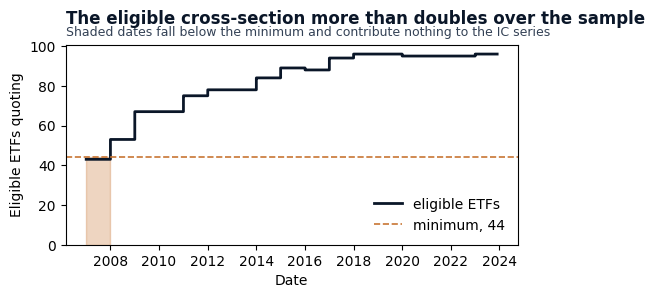

4,257 dates carry an eligible cross-section; 4,006 of them reach 44 ETFs and are scored, from 2008-01-02 to 2023-11-29


In [13]:
eligible_per_date = baseline.group_by("timestamp").len().sort("timestamp")
min_obs = int(eligible_per_date["len"].median() // 2)
scored = eligible_per_date.filter(pl.col("len") >= min_obs)

dates = eligible_per_date["timestamp"].to_numpy()
counts = eligible_per_date["len"].to_numpy()

fig, ax = plt.subplots(figsize=FIGSIZE["single_wide"])
ax.step(dates, counts, where="post", color=COLORS["blue"], linewidth=2, label="eligible ETFs")
ax.axhline(
    min_obs, color=COLORS["copper"], linestyle="--", linewidth=1.2, label=f"minimum, {min_obs}"
)
ax.fill_between(
    dates, 0, min_obs, where=counts < min_obs, color=COLORS["copper"], alpha=0.3, step="post"
)
ax.set_ylim(0, None)
ax.set_xlabel("Date")
ax.set_ylabel("Eligible ETFs quoting")
add_message_title(
    ax,
    "The eligible cross-section more than doubles over the sample",
    subtitle="Shaded dates fall below the minimum and contribute nothing to the IC series",
)
ax.legend(loc="lower right", frameon=False)
plt.show()

print(
    f"{eligible_per_date.height:,} dates carry an eligible cross-section; {scored.height:,} of "
    f"them reach {min_obs} ETFs and are scored, from {scored['timestamp'].min()} to "
    f"{scored['timestamp'].max()}"
)

In [14]:
ic = cross_sectional_ic_series(
    baseline,
    baseline,
    pred_col="momentum",
    ret_col=PRIMARY_LABEL,
    date_col="timestamp",
    entity_col="symbol",
    min_obs=min_obs,
).sort("timestamp")  # HAC autocovariances are meaningless over a permutation of time
stats = compute_ic_hac_stats(ic, ic_col="ic", label_horizon=PRIMARY_HORIZON)

print(
    f"Baseline: {LOOKBACK}-session momentum vs {PRIMARY_LABEL}, min cross-section {min_obs}, "
    f"eligible panel {baseline.height:,} rows"
)
print(
    f"  mean IC {stats['mean_ic']:.4f} over the {stats['n_periods']:,} scored dates, "
    f"{ic.height - stats['n_periods']:,} of the {ic.height:,} left out as too thin"
)
print(
    f"  HAC t {stats['t_stat']:.2f} (Bartlett, {stats['effective_lags']} lags), "
    f"naive t {stats['naive_t_stat']:.2f}, p {stats['p_value']:.3f}"
)

Baseline: 126-session momentum vs fwd_ret_21d, min cross-section 44, eligible panel 347,484 rows
  mean IC 0.0203 over the 4,006 scored dates, 251 of the 4,257 left out as too thin
  HAC t 1.08 (Bartlett, 20 lags), naive t 3.77, p 0.282


On the point-in-time eligible panel - the one `03_financial_features` builds features over
and `05_evaluation` scores them on - raw momentum earns a mean IC of 0.0203 against the
monthly label, averaged over the 4,006 dates that reach the 44-ETF minimum. The other 251 of
the 4,257 are the earliest in the panel, so the series is scored from 2008-01-02 rather than
from the first date momentum can be measured on. The naive standard error puts that IC at a
t-statistic of 3.77; the HAC standard error puts it at 1.08, with a p-value of 0.282. A
feature has to clear the second number.

## H. Artifacts and the audit record

Each label goes to `labels/<name>.parquet`, with a small JSON file beside it holding the
label's *digest* - a hash of its contents - along with the row count, the key columns, and
the digest of the price data it was built from. Two runs against different downloads write
the same file name and different digests, so a stored label can be traced to its data.

The cross-validation folds the modelling stages use are derived from this file's timeline,
so which rows land here also sets where the folds fall.

Section 7.2 closes a label definition with a record of what was decided: the anchor price,
the horizon, when the outcome resolves, how much of the forward window consecutive rows
share, and the base rate. The table below carries one row per label, and a last column
naming the notebook that opens the file first - `05_evaluation` for the monthly label it
scores features against, and the latent-factor notebooks for the weekly variant, which is
the second label the models are trained on.

In [15]:
for label_name in LABEL_NAMES:
    record = write_artifact(
        labels_df.select(["timestamp", "symbol", label_name]).drop_nulls(),
        LABELS_DIR / f"{label_name}.parquet",
        keys=["timestamp", "symbol"],
        written_by="02_labels",
        inputs={"market_data": MARKET_DATA_DIGEST},
    )
    print(f"{label_name}.parquet: {record['n_rows']:,} rows, digest {record['digest']}")

fwd_ret_21d.parquet: 468,562 rows, digest fb38c0259c37ef66
fwd_ret_5d.parquet: 470,162 rows, digest d35db10f6a851c96


In [16]:
audit = pl.DataFrame(
    [
        {
            "label": label_name,
            "anchor": "adjusted close at t",
            "horizon": f"{horizon} sessions",
            "resolves": f"close of session t+{horizon}",
            "overlap": f"{horizon - 1} sessions",
            "mean": round(dev[label_name][label_name].mean(), 4),
            "std": round(dev[label_name][label_name].std(), 4),
            "first reader": "05_evaluation" if label_name == PRIMARY_LABEL else "11a_pca",
        }
        for label_name, horizon in HORIZONS.items()
    ]
)
audit

label,anchor,horizon,resolves,overlap,mean,std,first reader
str,str,str,str,str,f64,f64,str
"""fwd_ret_21d""","""adjusted close at t""","""21 sessions""","""close of session t+21""","""20 sessions""",0.0059,0.0612,"""05_evaluation"""
"""fwd_ret_5d""","""adjusted close at t""","""5 sessions""","""close of session t+5""","""4 sessions""",0.0015,0.0311,"""11a_pca"""


## Key takeaways

1. **Write the label as a formula over tradable prices:** which price at which time, to
   which price at which time. Written that way it can be checked against the backtest that
   has to fill it.
2. **Check the forward window with assertions.** Each property in Section D fails without
   raising an error and leaves plausible numbers behind: a tail filled in where it should
   be null, a window spanning a data gap, a label built across two symbols.
3. **Cut the development window on the label's endpoint.** A row observed before the holdout
   but resolving inside it is a holdout row; a filter on the observation date leaves it in
   the development set.
4. **Count the information the rows carry.** Overlapping windows make the row count a poor
   guide to how much evidence there is; the effective count measures what is left. The purge
   gap between folds is a separate quantity, set by the forward window: $N_{eff}$ moves with
   sampling density and panel length, the gap stays at the horizon.
5. **Establish the floor before building features, on the same rows the features will be
   scored on.** A baseline measured over a wider universe than the features it gates sets
   the bar in the wrong place, and a date whose cross-section is too small to rank should
   count in neither.

**Known limitations.** Close-to-close is not the backtest's next-open execution and nothing
here measures the gap; the universe is a fixed, backward-looking list carrying the
survivorship bias `01_feasibility_analysis` documents; the baseline is one signal, one lookback.

**Next**: `03_financial_features.py` builds the feature matrix over the same eligible panel,
and `05_evaluation.py` is the first notebook to open these label files, scoring those
features against the primary label.